Programa que utiliza el método de la bisección para determinar el valor de la incertidumbre sistemática imponiendo un valor de $\chi^2_{red}$ = 1, y realiza el ajuste lineal a los datos experimentales utilizando la nueva incertidumbre efectiva.

sigma_int = 0.02870282
m = 0.00028002 ± 0.00001200 m^{-1}
n = -1.91507585 ± 0.02127763
chi2 = 7.000000
chi2 reducido = 1.000000
r (Pearson) = 0.994243


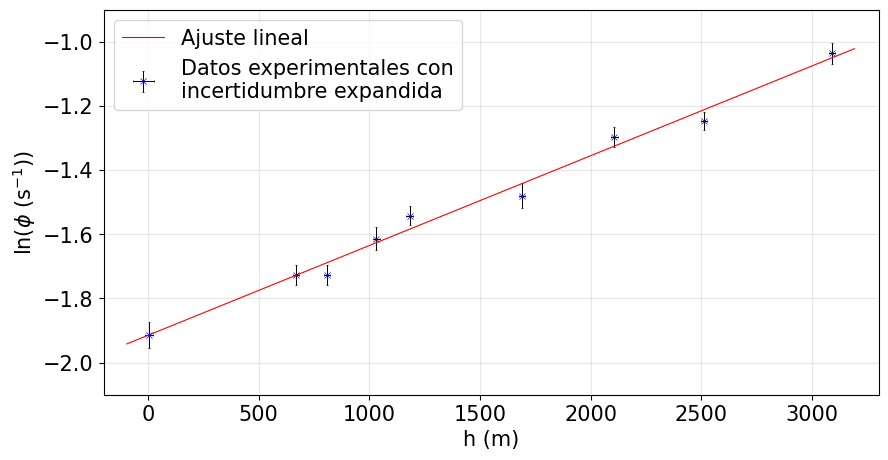

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Extraigo los datos del archivo en una matriz Nx4
Matriz_datos = np.loadtxt("Datos_Altitud_Flujo.txt", skiprows = 1)

# Extraigo las columnas de la matriz
Altitud = Matriz_datos[:, 0]
Inc_altitud = Matriz_datos[:, 1]
Flujo = Matriz_datos[:, 2]
Inc_flujo = Matriz_datos[:, 3]

# Calculo el ln(flujo)
ln_flujo = np.log(Flujo)

# Calculo su incertidumbre por propagación de errores
Inc_ln_flujo = Inc_flujo / Flujo

grados_libertad = len(Altitud) - 2

def ajuste_y_chi2_reducido(sigma_int):
    
    """Devuelve (m, n, inc_m, inc_n, chi2, chi2_reducido) para un sigma_int dado"""

    sigma_total = np.sqrt(Inc_ln_flujo**2 + sigma_int**2)
    pesos = 1.0 / sigma_total
    coef, cov = np.polyfit(Altitud, ln_flujo, deg=1, w=pesos, cov=True)
    m, n = coef
    inc_m, inc_n = np.sqrt(np.diag(cov))
    ln_flujo_modelo = m * Altitud + n
    chi2 = np.sum(((ln_flujo - ln_flujo_modelo) / sigma_total) ** 2)
    chi2_reducido = chi2 / grados_libertad
    return m, n, inc_m, inc_n, chi2, chi2_reducido

# Si ya es <= 1 con sigma_int = 0, no hace falta sumar incertidumbre interna
m0, n0, inc_m0, inc_n0, chi20, chi2_red0 = ajuste_y_chi2_reducido(0.0)

if chi2_red0 <= 1.0:
    sigma_int = 0.0
    m, n, inc_m, inc_n, chi2, chi2_reducido = m0, n0, inc_m0, inc_n0, chi20, chi2_red0

else:
    # Busqueda por biseccion de sigma_int tal que chi2_reducido = 1
    izq, der = 0.0, np.max(Inc_ln_flujo)

    # Garantizamos que un extremo (izq) tenga chi2_reducido > 1 y el otro (der) < 1, es decir, encerramos la solución
    while ajuste_y_chi2_reducido(der)[-1] > 1.0:
        der *= 2.0

    tol = 1e-8
    max_iter = 200

    for i in range(max_iter):

        mid = 0.5 * (izq + der)
        chi2_red_mid = ajuste_y_chi2_reducido(mid)[-1]

        if abs(chi2_red_mid - 1.0) < tol:
            break

        if chi2_red_mid > 1.0:
            izq = mid

        else:
            der = mid

    sigma_int = 0.5 * (izq + der)
    m, n, inc_m, inc_n, chi2, chi2_reducido = ajuste_y_chi2_reducido(sigma_int)

r = np.corrcoef(Altitud, ln_flujo)[0, 1]

# Representacion grafica del ajuste final
fig, ax = plt.subplots(figsize=(10, 5))
ax.set(xlim=(-200, 3300), ylim=(-2.1, -0.9))
ax.set_xlabel("h (m)", fontsize=15)
ax.set_ylabel(r"ln($\phi$ (s$^{-1}$))", fontsize=15)
ax.tick_params(axis="both", labelsize=15)

# Calculo la incertidumbre total usando propagación cuadrática de errores
sigma_total_final = np.sqrt(Inc_ln_flujo**2 + sigma_int**2)

# Grafico las barras de error con la incertidumbre total
ax.errorbar(Altitud, ln_flujo, fmt = "x", markeredgewidth=0.5, markersize = 5, color = "blue", xerr = Inc_altitud, yerr = sigma_total_final, ecolor = "black", elinewidth = 0.7, capsize = 1, capthick = 0.7, label = "Datos experimentales con\nincertidumbre expandida")

# Grafico la recta de ajuste
h_ajuste = np.linspace(np.min(Altitud) - 100, np.max(Altitud) + 100, 200)
ln_flujo_ajuste = m * h_ajuste + n
ax.plot(h_ajuste, ln_flujo_ajuste, color="red", linewidth=0.8, label="Ajuste lineal")
ax.grid(alpha=0.3)
ax.legend(loc="upper left", fontsize=15)

# Escribo los resultados por pantalla
print(f"sigma_int = {sigma_int:.8f}")
print(f"m = {m:.8f} ± {inc_m:.8f} m^{{-1}}")
print(f"n = {n:.8f} ± {inc_n:.8f}")
print(f"chi2 = {chi2:.6f}")
print(f"chi2 reducido = {chi2_reducido:.6f}")
print(f"r (Pearson) = {r:.6f}")

# Guardo los resultados en un fichero
with open("Parametros_ajuste_con_incertidumbre_efectiva.txt", "w") as f:
    f.write(f"sigma_int = {sigma_int:.8f}\n")
    f.write(f"m = {m:.8f} ± {inc_m:.8f} (m^{{-1}})\n")
    f.write(f"n = {n:.8f} ± {inc_n:.8f}\n")
    f.write(f"chi2 = {chi2:.6f}\n")
    f.write(f"chi2_reducido = {chi2_reducido:.6f}\n")
    f.write(f"r_pearson = {r:.6f}\n")

fig.savefig("Ajuste_lineal_con_incertidumbre_efectiva.png", dpi=300)
plt.show()